In [15]:
from google.colab import files
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



uploaded = files.upload()

Saving 1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv to 1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1) (4).csv


In [16]:
df = pd.read_csv(
    "1776311302-P3-Car Market Trends Analysis with Car Dekho Data (1).csv"
)

In [12]:
print("Dataset loaded successfully!")
print("Shape:", df.shape)

Dataset loaded successfully!
Shape: (301, 9)


In [13]:
print("Total Records:",len(df))
print("Total Features:",len(df.columns))
print("Unique Car Models:",df["Car_Name"].nunique())
print("Year Range:",df["Year"].min(), "-", df["Year"].max())

print("\nFuel Type:")
print(df["Fuel_Type"].value_counts())

Total Records: 301
Total Features: 9
Unique Car Models: 98
Year Range: 2003 - 2018

Fuel Type:
Fuel_Type
Petrol    239
Diesel     60
CNG         2
Name: count, dtype: int64


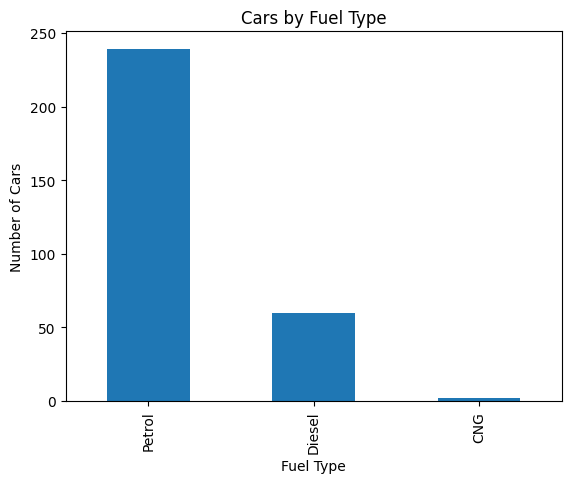

In [14]:
df["Fuel_Type"].value_counts().plot(kind="bar")
plt.title("Cars by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Number of Cars")
plt.show()

In [17]:
print(df.groupby("Fuel_Type")["Selling_Price"].mean().round(2))
print(df.groupby("Seller_Type")["Selling_Price"].mean().round(2))
print(df.groupby("Transmission")["Selling_Price"].mean().round(2))

Fuel_Type
CNG        3.10
Diesel    10.28
Petrol     3.26
Name: Selling_Price, dtype: float64
Seller_Type
Dealer        6.72
Individual    0.87
Name: Selling_Price, dtype: float64
Transmission
Automatic    9.42
Manual       3.93
Name: Selling_Price, dtype: float64


In [19]:
print("Correlation:",round(df["Present_Price"].corr(df["Selling_Price"]),3))

Correlation: 0.879


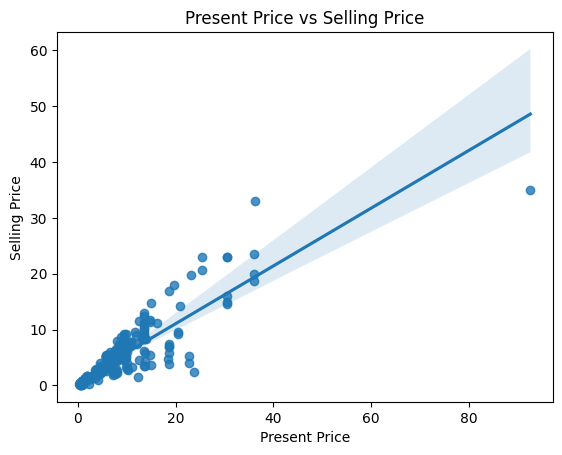

In [20]:
sns.regplot(data=df,x="Present_Price",y="Selling_Price")
plt.title("Present Price vs Selling Price")
plt.xlabel("Present Price")
plt.ylabel("Selling Price")
plt.show()

In [21]:
year_price=df.groupby("Year")["Selling_Price"].mean()
print(year_price.round(2))

Year
2003    1.30
2004    1.50
2005    2.49
2006    1.44
2007    0.16
2008    1.00
2009    2.82
2010    5.26
2011    2.38
2012    3.84
2013    3.54
2014    4.76
2015    5.93
2016    5.21
2017    6.21
2018    9.25
Name: Selling_Price, dtype: float64


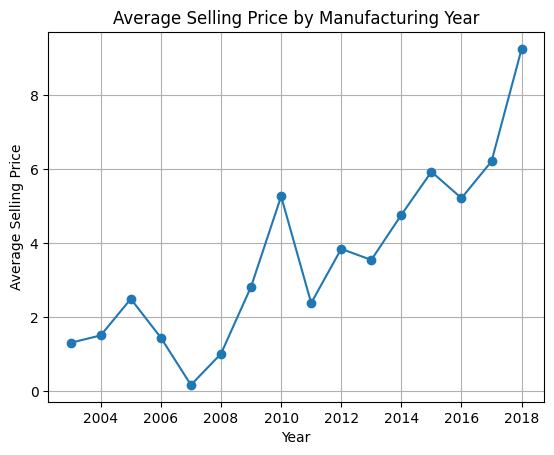

In [22]:
plt.plot(year_price.index,year_price.values,marker="o")
plt.title("Average Selling Price by Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Average Selling Price")
plt.grid(True)
plt.show()

In [23]:
cols=["Year","Selling_Price","Present_Price","Kms_Driven","Owner"]
corr=df[cols].corr()
print(corr["Selling_Price"].sort_values(ascending=False).round(3))

Selling_Price    1.000
Present_Price    0.879
Year             0.236
Kms_Driven       0.029
Owner           -0.088
Name: Selling_Price, dtype: float64


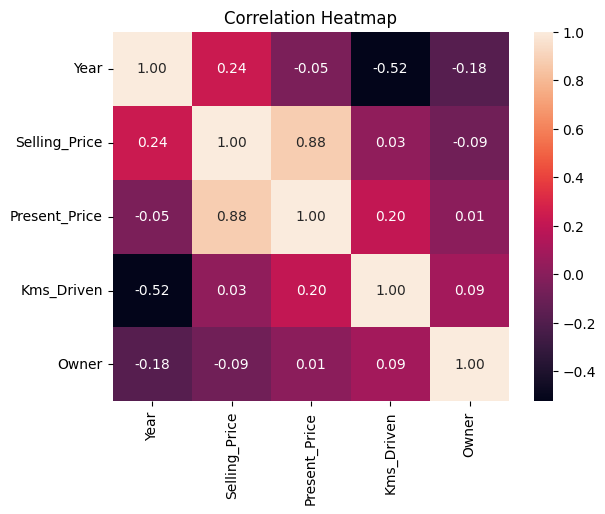

In [24]:
sns.heatmap(corr,annot=True,fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()